## Autoencoder-Based Anomaly Detection for Financial Transactions

---

## 1. Project Introduction

This notebook applies an **autoencoder** for **anomaly detection** in financial transaction data.

Anomaly detection means finding records that look unusual compared with normal behaviour.

In this project, we use financial transaction data to answer one main question:

> Can an autoencoder learn normal transaction behaviour and help identify suspicious transactions using reconstruction error?

---

## Business Context

In finance, suspicious transactions are often rare.

Most transactions are normal.  
Only a small number may be fraudulent, suspicious, or unusual.

This creates a common business problem:

| Business Challenge | Meaning |
|---|---|
| Fraud is rare | Suspicious cases are much fewer than normal cases |
| Manual checking is expensive | Analysts cannot review every transaction |
| Suspicious patterns can change | Fraud behaviour may not always look the same |
| Early detection matters | Faster detection can reduce risk and financial loss |

An autoencoder can help by learning what normal transactions usually look like.

Transactions that the model cannot reconstruct well may be treated as suspicious and investigated further.

---

## Dataset Used

We use the **PaySim financial transaction dataset**.

This dataset simulates mobile-money transactions and contains fraud labels.

The dataset includes transaction information such as:

| Column Type | Example Meaning |
|---|---|
| Transaction type | Cash-out, transfer, payment, debit |
| Transaction amount | Value of the transaction |
| Sender balance | Balance before and after transaction |
| Receiver balance | Balance before and after transaction |
| Fraud label | Whether the transaction is fraud or not |

The fraud label will be used later only for evaluation.

It will not be used as an input feature when training the autoencoder.

---

## Main Machine Learning Idea

The autoencoder learns from normal transaction patterns.

The logic is:

`normal transaction → reconstructed well → low reconstruction error`

`suspicious transaction → reconstructed poorly → high reconstruction error`

A high reconstruction error does not automatically prove fraud.

It means:

> This transaction looks unusual and should be investigated.

---

## Notebook Workflow

This notebook follows a clear step-by-step workflow:

| Step | What We Do |
|---|---|
| 1 | Understand the business problem |
| 2 | Learn anomaly detection theory |
| 3 | Load the PaySim dataset |
| 4 | Understand class imbalance |
| 5 | Prepare features for modelling |
| 6 | Train the autoencoder mainly on normal transactions |
| 7 | Calculate reconstruction error |
| 8 | Set an anomaly threshold |
| 9 | Flag suspicious transactions |
| 10 | Evaluate results using fraud labels |
| 11 | Build BI-ready charts |
| 12 | Interpret results from a business point of view |

---

## Goal of This Notebook

The goal is not only to build a model.

The goal is to understand how autoencoder-based anomaly detection can support financial fraud analysis.

By the end of this notebook, we should be able to explain:

- what anomaly detection means,
- how autoencoders detect unusual records,
- what reconstruction error means,
- how thresholding works,
- how to evaluate suspicious transaction detection,
- and how to communicate the results using clear BI-style charts.

## 2. Theory Recap: Autoencoder-Based Anomaly Detection

Before building the model, we need to understand the main idea clearly.

---

### 2.1 What Is Anomaly Detection?

Anomaly detection means finding records that look different from normal behaviour.

In this project:

| Term | Simple Meaning |
|---|---|
| Normal transaction | A common transaction pattern |
| Suspicious transaction | A transaction that looks unusual |
| Anomaly detection | Finding unusual transactions |

An anomaly does not always mean fraud.

It means:

> This transaction is different enough that it should be investigated.

---

### 2.2 Why Use an Autoencoder?

An autoencoder is a neural network that learns to rebuild its input.

It has three main parts:

| Part | Simple Meaning |
|---|---|
| Encoder | Compresses the input |
| Bottleneck | Stores the compressed pattern |
| Decoder | Rebuilds the original input |

The model learns normal transaction behaviour by trying to reconstruct normal transactions.

---

### 2.3 How Autoencoders Detect Suspicious Transactions

The autoencoder usually reconstructs normal transactions well.

That creates a low reconstruction error.

Suspicious transactions may not follow normal patterns.

The autoencoder may reconstruct them poorly.

That creates a high reconstruction error.

| Transaction Type | Reconstruction Quality | Error |
|---|---|---|
| Normal transaction | Reconstructed well | Low error |
| Suspicious transaction | Reconstructed poorly | High error |

---

### 2.4 What Is Reconstruction Error?

Reconstruction error measures the difference between:

`original transaction features`

and

`reconstructed transaction features`

Simple meaning:

> Reconstruction error tells us how badly the model rebuilt the transaction.

A higher reconstruction error means the transaction looks less familiar to the model.

---

### 2.5 What Is a Threshold?

A threshold is the cutoff used to decide whether a transaction is normal or suspicious.

Example:

| Reconstruction Error | Threshold | Result |
|---:|---:|---|
| 0.02 | 0.10 | Normal |
| 0.07 | 0.10 | Normal |
| 0.15 | 0.10 | Suspicious |
| 0.30 | 0.10 | Suspicious |

The threshold turns reconstruction error into a decision.

---

### 2.6 False Positives and False Negatives

Anomaly detection can make mistakes.

| Error Type | Simple Meaning | Example |
|---|---|---|
| False positive | Normal transaction flagged as suspicious | False alarm |
| False negative | Fraud transaction missed by the model | Missed risk |

In fraud detection, both are important.

Too many false positives waste analyst time.

Too many false negatives allow real fraud to pass through.

---

### 2.7 How We Evaluate the Model

Because the PaySim dataset has fraud labels, we can evaluate the anomaly detector.

We will use:

| Metric | Meaning |
|---|---|
| Precision | Of flagged transactions, how many were truly fraud? |
| Recall | Of all fraud transactions, how many did we catch? |
| F1-score | Balance between precision and recall |
| Confusion matrix | Correct and wrong predictions |
| Reconstruction error distribution | Shows how normal and fraud errors differ |

---

### 2.8 Business Meaning

The autoencoder does not directly say:

`This is fraud.`

It says:

`This transaction has high reconstruction error.`

Then we interpret high-error transactions as suspicious.

In business terms, the model helps create a risk signal that can support fraud investigation.

---

### 2.9 Final Theory Summary

The workflow is:

`normal transactions → train autoencoder → reconstruct transactions → calculate error → apply threshold → flag suspicious transactions`

This is the main logic behind autoencoder-based anomaly detection.

## 3. Environment Setup

This section imports the libraries needed for the anomaly detection workflow.

We use:

| Library | Purpose |
|---|---|
| NumPy | Numerical calculations |
| Pandas | Data loading and analysis |
| Matplotlib | Professional charts |
| TensorFlow / Keras | Autoencoder model |
| Scikit-learn | Preprocessing, splitting, and evaluation |

We also set random seeds so that results are more stable when the notebook is re-run.

In [4]:
# ============================================================
# Step 3: Environment Setup and Imports
# ============================================================

# Core data libraries
import numpy as np
import pandas as pd

# Charting library
import matplotlib.pyplot as plt

# Deep learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# File handling
from pathlib import Path

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

2026-06-08 10:49:29.759041: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Libraries imported successfully.
TensorFlow version: 2.16.2
Pandas version: 3.0.3
NumPy version: 1.26.4


## 4. Load the PaySim Dataset

Now we load the PaySim financial transaction dataset.

The dataset has already been downloaded into the local `data/paysim/` folder.

The main dataset contains mobile-money transaction records.

Important:

- The fraud label is kept for evaluation.
- The fraud label is not used as an input feature for training the autoencoder.
- The autoencoder will learn transaction behaviour from the feature columns only.

In [5]:
# ============================================================
# Step 4: Load the PaySim Dataset
# ============================================================

# Dataset folder inside the project
data_path = Path("data/paysim")

# Find CSV files in the dataset folder
csv_files = list(data_path.glob("*.csv"))

print("CSV files found:", len(csv_files))

for file in csv_files:
    print("-", file.name)

# Safety check before loading
if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file found in data/paysim. "
        "Please check that the PaySim dataset was downloaded and unzipped correctly."
    )

# Load the first CSV file found
transactions = pd.read_csv(csv_files[0])

print("\nDataset loaded successfully.")
print("Rows:", transactions.shape[0])
print("Columns:", transactions.shape[1])

display(transactions.head())

CSV files found: 1
- PS_20174392719_1491204439457_log.csv

Dataset loaded successfully.
Rows: 6362620
Columns: 11


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 5. Dataset Structure Check

Before building the anomaly detection model, we first inspect the dataset.

This step checks:

| Check | Why It Matters |
|---|---|
| Dataset shape | Shows number of rows and columns |
| Column names | Helps us understand available features |
| Data types | Shows numeric and categorical columns |
| Missing values | Missing values must be handled before modelling |
| Fraud label columns | Helps identify target columns used later for evaluation |

This step gives us a clean starting point before preprocessing.

In [6]:
# ============================================================
# Step 5: Dataset Structure Check
# ============================================================

print("Dataset shape:")
print("Rows:", transactions.shape[0])
print("Columns:", transactions.shape[1])

print("\nColumn names:")
print(transactions.columns.tolist())

print("\nData types:")
display(transactions.dtypes.to_frame(name="Data Type"))

print("\nMissing values:")
missing_values = (
    transactions
    .isna()
    .sum()
    .reset_index()
)

missing_values.columns = ["Column", "Missing Values"]
missing_values["Missing %"] = (
    missing_values["Missing Values"] / len(transactions) * 100
).round(3)

display(missing_values)

print("\nFirst 5 rows:")
display(transactions.head())

Dataset shape:
Rows: 6362620
Columns: 11

Column names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data types:


,Data Type
step,int64
type,str
amount,float64
nameOrig,str
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,str
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64



Missing values:


,Column,Missing Values,Missing %
0,step,0,0.0
1,type,0,0.0
2,amount,0,0.0
3,nameOrig,0,0.0
4,oldbalanceOrg,0,0.0
5,newbalanceOrig,0,0.0
6,nameDest,0,0.0
7,oldbalanceDest,0,0.0
8,newbalanceDest,0,0.0
9,isFraud,0,0.0



First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


| Column           | Role                                |
| ---------------- | ----------------------------------- |
| `step`           | Time step of transaction            |
| `type`           | Transaction type                    |
| `amount`         | Transaction amount                  |
| `nameOrig`       | Sender/customer ID                  |
| `oldbalanceOrg`  | Sender balance before transaction   |
| `newbalanceOrig` | Sender balance after transaction    |
| `nameDest`       | Receiver/customer ID                |
| `oldbalanceDest` | Receiver balance before transaction |
| `newbalanceDest` | Receiver balance after transaction  |
| `isFraud`        | Fraud label for evaluation          |
| `isFlaggedFraud` | Rule-based fraud flag               |


### Dataset Structure Check — Conclusion

The dataset contains financial transaction records with both numeric and categorical columns.

The key fraud label is `isFraud`.

This column will be used only for evaluation after the autoencoder creates anomaly scores.

The transaction ID columns `nameOrig` and `nameDest` are not useful as direct model inputs because they represent customer/account identifiers.

The main useful modelling columns are:

| Feature Type | Columns |
|---|---|
| Time feature | `step` |
| Transaction type | `type` |
| Amount feature | `amount` |
| Sender balance features | `oldbalanceOrg`, `newbalanceOrig` |
| Receiver balance features | `oldbalanceDest`, `newbalanceDest` |
| Evaluation label | `isFraud` |

Next, we check the fraud distribution to understand how imbalanced the dataset is.

## 6. Fraud Distribution Check

Before modelling, we check how many transactions are fraud and how many are normal.

This is important because fraud datasets are usually highly imbalanced.

In fraud detection:

| Class | Meaning |
|---|---|
| `0` | Normal transaction |
| `1` | Fraud transaction |

If fraud cases are very rare, accuracy alone is not useful.

A model can look accurate by predicting almost everything as normal, which is deeply convenient and completely useless. 

In [7]:
# ============================================================
# Step 6: Fraud Distribution Check
# ============================================================

fraud_distribution = (
    transactions["isFraud"]
    .value_counts()
    .rename_axis("isFraud")
    .reset_index(name="Transactions")
)

fraud_distribution["Label"] = fraud_distribution["isFraud"].map({
    0: "Normal Transaction",
    1: "Fraud Transaction"
})

fraud_distribution["Share %"] = (
    fraud_distribution["Transactions"] / len(transactions) * 100
).round(4)

fraud_distribution = fraud_distribution[
    ["Label", "Transactions", "Share %"]
]

display(fraud_distribution)

normal_count = fraud_distribution.loc[
    fraud_distribution["Label"] == "Normal Transaction", 
    "Transactions"
].iloc[0]

fraud_count = fraud_distribution.loc[
    fraud_distribution["Label"] == "Fraud Transaction", 
    "Transactions"
].iloc[0]

fraud_rate = fraud_distribution.loc[
    fraud_distribution["Label"] == "Fraud Transaction", 
    "Share %"
].iloc[0]

print("Normal transactions:", normal_count)
print("Fraud transactions:", fraud_count)
print("Fraud rate:", fraud_rate, "%")

,Label,Transactions,Share %
0,Normal Transaction,6354407,99.8709
1,Fraud Transaction,8213,0.1291


Normal transactions: 6354407
Fraud transactions: 8213
Fraud rate: 0.1291 %


### Fraud Distribution — Conclusion

The dataset is extremely imbalanced.

| Class | Transactions | Share |
|---|---:|---:|
| Normal Transaction | 6,354,407 | 99.8709% |
| Fraud Transaction | 8,213 | 0.1291% |

Fraud transactions represent only **0.1291%** of the dataset.

This means fraud is very rare compared with normal transaction behaviour.

Because of this imbalance, accuracy is not a reliable metric.

A model could predict almost every transaction as normal and still appear highly accurate.

For this reason, this notebook focuses on anomaly detection logic:

`learn normal behaviour → calculate reconstruction error → flag high-error transactions as suspicious`

Next, we create a professional chart to visualise the class imbalance clearly.

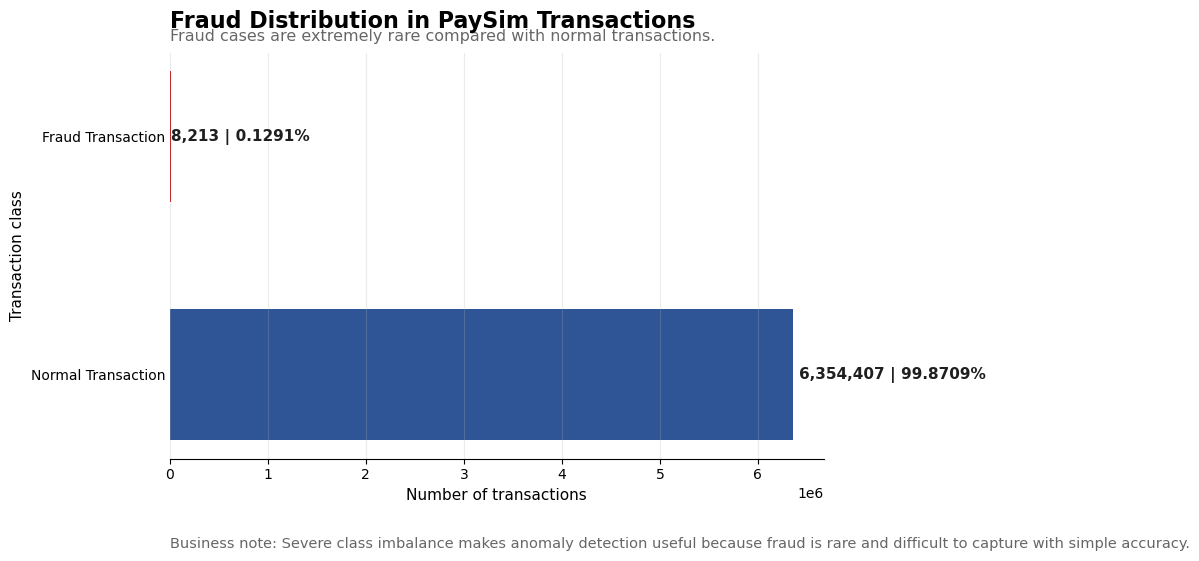

In [8]:
# ============================================================
# Step 7: BI-Ready Fraud Distribution Chart
# ============================================================

# Chart colors
COLOR_NORMAL = "#2F5597"
COLOR_FRAUD = "#C00000"
COLOR_TEXT = "#1F1F1F"
COLOR_GREY = "#666666"

chart_data = fraud_distribution.copy()

fig, ax = plt.subplots(figsize=(10.5, 5.8))

bars = ax.barh(
    chart_data["Label"],
    chart_data["Transactions"],
    color=[COLOR_NORMAL, COLOR_FRAUD],
    height=0.55
)

# Add value labels
for bar, transactions_count, share in zip(
    bars,
    chart_data["Transactions"],
    chart_data["Share %"]
):
    ax.text(
        bar.get_width() * 1.01,
        bar.get_y() + bar.get_height() / 2,
        f"{transactions_count:,.0f} | {share:.4f}%",
        va="center",
        fontsize=11,
        fontweight="bold",
        color=COLOR_TEXT
    )

# Chart formatting
ax.set_title(
    "Fraud Distribution in PaySim Transactions",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.03,
    "Fraud cases are extremely rare compared with normal transactions.",
    transform=ax.transAxes,
    fontsize=11.5,
    color=COLOR_GREY
)

ax.set_xlabel("Number of transactions", fontsize=11)
ax.set_ylabel("Transaction class", fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", alpha=0.25)
ax.tick_params(axis="y", length=0)

ax.text(
    0,
    -0.22,
    "Business note: Severe class imbalance makes anomaly detection useful because fraud is rare and difficult to capture with simple accuracy.",
    transform=ax.transAxes,
    fontsize=10.5,
    color=COLOR_GREY
)

plt.tight_layout()
plt.show()

## 8. Create a Practical Working Sample

The full PaySim dataset contains more than 6 million transactions.

Training directly on the full dataset can be slow on a local machine.

For this learning notebook, we create a smaller working sample.

We keep:

| Transaction Type | Sampling Strategy |
|---|---|
| Normal transactions | Random sample of 100,000 records |
| Fraud transactions | Keep all fraud records |

This keeps the notebook practical while still preserving all known fraud cases for evaluation.

The fraud label is still used only for evaluation, not as an input feature.

In [ ]:
# ============================================================
# Step 8: Create a Practical Working Sample
# ============================================================

# Separate normal and fraud transactions

normal_transactions = transactions[transactions["isFraud"] == 0]
fraud_transactions = transactions[transactions["isFraud"] == 1]

# Sample normal transactions for faster notebook training

normal_sample_size = 100_000

normal_sample = normal_transactions.sample(
    n=normal_sample_size,
    random_state=42
)

# Keep all fraud transactions

fraud_sample = fraud_transactions.copy()

# Combine normal sample and all fraud records

working_data = pd.concat(
    [normal_sample, fraud_sample],
    axis=0
).sample(frac=1, random_state=42).reset_index(drop=True)

# Create summary table
working_distribution = (
    working_data["isFraud"]
    .value_counts()
    .rename_axis("isFraud")
    .reset_index(name="Transactions")
)

working_distribution["Label"] = working_distribution["isFraud"].map({
    0: "Normal Transaction",
    1: "Fraud Transaction"
})

working_distribution["Share %"] = (
    working_distribution["Transactions"] / len(working_data) * 100
).round(3)

working_distribution = working_distribution[
    ["Label", "Transactions", "Share %"]
]

print("Working dataset created successfully.")
print("Rows:", working_data.shape[0])
print("Columns:", working_data.shape[1])

display(working_distribution)

Working dataset created successfully.
Rows: 108213
Columns: 11


,Label,Transactions,Share %
0,Normal Transaction,100000,92.41
1,Fraud Transaction,8213,7.59


### Working Sample — Conclusion

A smaller working dataset was created for practical local training.

The original dataset contains more than 6 million transactions.

For this notebook, we kept:

| Transaction Type | Strategy |
|---|---|
| Normal transactions | Random sample of 100,000 records |
| Fraud transactions | All fraud records kept |

This gives the autoencoder enough normal behaviour to learn from while keeping all known fraud cases for later evaluation.

The working dataset will make model training faster and easier to manage.

# Feature Selection

| Column                      | Use? | Reason                                               |
| --------------------------- | ---- | ---------------------------------------------------- |
| `isFraud`                   | No   | Evaluation label only                                |
| `isFlaggedFraud`            | No   | Existing rule-based fraud flag, can leak fraud logic |
| `nameOrig`                  | No   | Sender ID, too many unique values                    |
| `nameDest`                  | No   | Receiver ID, too many unique values                  |
| `type`                      | Yes  | Transaction type is useful                           |
| numeric transaction columns | Yes  | Main transaction behaviour features                  |


## 9. Feature Selection

Now we select the columns used for autoencoder training.

The autoencoder should learn transaction behaviour from useful feature columns.

Some columns must not be used as model inputs.

| Column | Decision | Reason |
|---|---|---|
| `isFraud` | Exclude | This is the fraud label, used only for evaluation |
| `isFlaggedFraud` | Exclude | This is an existing fraud-rule flag and may leak fraud information |
| `nameOrig` | Exclude | Sender/customer ID, too many unique values |
| `nameDest` | Exclude | Receiver/customer ID, too many unique values |
| `type` | Include | Transaction type is useful categorical information |
| Numeric transaction columns | Include | They describe transaction behaviour |

The goal is to train the autoencoder using transaction behaviour features, not the fraud label.

In [10]:
# ============================================================
# Step 9: Select Features for Autoencoder Modelling
# ============================================================

# Label column used only for evaluation
label_column = "isFraud"

# Columns excluded from model input
excluded_columns = [
    "isFraud",          # fraud label, used only later for evaluation
    "isFlaggedFraud",   # rule-based fraud flag, excluded to avoid leakage
    "nameOrig",         # sender ID, not useful directly for autoencoder input
    "nameDest"          # receiver ID, not useful directly for autoencoder input
]

# Feature columns used as autoencoder input
feature_columns = [
    column for column in working_data.columns 
    if column not in excluded_columns
]

# Separate features and labels
features = working_data[feature_columns].copy()
labels = working_data[label_column].copy()

print("Feature columns used for modelling:")
print(feature_columns)

print("\nNumber of feature columns:", len(feature_columns))
print("Feature dataset shape:", features.shape)
print("Label shape:", labels.shape)

print("\nFeature preview:")
display(features.head())

Feature columns used for modelling:
['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

Number of feature columns: 7
Feature dataset shape: (108213, 7)
Label shape: (108213,)

Feature preview:


,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
0,398,PAYMENT,28860.39,32174.00,3313.61,0.00,0.00
1,206,CASH_IN,109088.87,12984.00,122072.87,0.00,0.00
2,13,TRANSFER,691054.46,45096.39,0.00,1698444.13,2389498.59
3,260,PAYMENT,4789.25,29979.00,25189.75,0.00,0.00
4,178,PAYMENT,4031.31,0.00,0.00,0.00,0.00


### Feature Selection — Conclusion

The feature selection step created the modelling dataset.

The autoencoder will use the following transaction behaviour columns:

| Feature | Meaning |
|---|---|
| `step` | Time step of the transaction |
| `type` | Type of transaction |
| `amount` | Transaction amount |
| `oldbalanceOrg` | Sender balance before transaction |
| `newbalanceOrig` | Sender balance after transaction |
| `oldbalanceDest` | Receiver balance before transaction |
| `newbalanceDest` | Receiver balance after transaction |

The following columns were excluded:

| Excluded Column | Reason |
|---|---|
| `isFraud` | Fraud label, used only for evaluation |
| `isFlaggedFraud` | Existing rule-based fraud flag, excluded to avoid leakage |
| `nameOrig` | Sender ID, not useful directly as a model input |
| `nameDest` | Receiver ID, not useful directly as a model input |

This keeps the model focused on transaction behaviour rather than labels or account identifiers.

## 10. Identify Numeric and Categorical Features

The autoencoder needs numeric input.

The dataset contains:

| Feature Type | Example |
|---|---|
| Numeric features | `amount`, balances, `step` |
| Categorical features | `type` |

Numeric features will be scaled using `StandardScaler`.

The transaction type column will be converted into numeric columns using `OneHotEncoder`.

This preprocessing is needed because neural networks cannot directly learn from text values like `PAYMENT` or `TRANSFER`.

In [11]:
# ============================================================
# Step 10: Identify Numeric and Categorical Features
# ============================================================

# Numeric columns are numbers that can be scaled
numeric_columns = features.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical columns are text/category columns that need encoding
categorical_columns = features.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numeric columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

print("\nTotal numeric columns:", len(numeric_columns))
print("Total categorical columns:", len(categorical_columns))

Numeric columns:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

Categorical columns:
['type']

Total numeric columns: 6
Total categorical columns: 1


### Numeric and Categorical Features — Conclusion

The selected model features were separated into numeric and categorical groups.

| Feature Type | Columns | Processing Needed |
|---|---|---|
| Numeric | `step`, `amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest` | Scale using `StandardScaler` |
| Categorical | `type` | Convert using `OneHotEncoder` |

This separation is required because the autoencoder needs numeric input.

The transaction type column contains text values such as `PAYMENT`, `TRANSFER`, and `CASH_OUT`.

These text values must be converted into numeric columns before training.

## 11. Create Train, Validation, and Test Sets

For autoencoder-based anomaly detection, the model should learn normal transaction behaviour.

So the training and validation sets contain only normal transactions.

The test set contains both normal and fraud transactions.

| Dataset | Content | Purpose |
|---|---|---|
| Training set | Normal transactions only | Model learns normal behaviour |
| Validation set | Normal transactions only | Checks reconstruction quality during training |
| Test set | Normal + fraud transactions | Final anomaly detection evaluation |

The fraud label is not used as a training target.

For the autoencoder:

`input features = target features`

The fraud label is used later only to evaluate whether high reconstruction error matches real fraud cases.

In [13]:
# ============================================================
# Step 11: Create Train, Validation, and Test Sets
# ============================================================

# Separate normal and fraud records from the working dataset
normal_data = working_data[working_data["isFraud"] == 0].copy()
fraud_data = working_data[working_data["isFraud"] == 1].copy()

# First split:
# 70% normal transactions for training
# 30% normal transactions kept for validation and normal test
normal_train_data, remaining_normal_data = train_test_split(
    normal_data,
    test_size=0.30,
    random_state=42
)

# Second split:
# Split the remaining normal transactions into validation and normal test sets
normal_val_data, normal_test_data = train_test_split(
    remaining_normal_data,
    test_size=0.50,
    random_state=42
)

# Keep all fraud records for final testing
fraud_test_data = fraud_data.copy()

# Final test set contains normal test transactions + all fraud transactions
test_data = pd.concat(
    [normal_test_data, fraud_test_data],
    axis=0
).sample(frac=1, random_state=42).reset_index(drop=True)

# Create feature sets
train_features = normal_train_data[feature_columns].copy()
val_features = normal_val_data[feature_columns].copy()
test_features = test_data[feature_columns].copy()

# Create label sets
# Labels are NOT used as autoencoder targets.
# They are kept only for final evaluation.
train_labels = normal_train_data["isFraud"].copy()
val_labels = normal_val_data["isFraud"].copy()
test_labels = test_data["isFraud"].copy()

print("Training features:", train_features.shape)
print("Validation features:", val_features.shape)
print("Test features:", test_features.shape)

print("\nTraining fraud count:", train_labels.sum())
print("Validation fraud count:", val_labels.sum())
print("Test fraud count:", test_labels.sum())

print("\nTest label distribution:")
display(
    test_labels
    .value_counts()
    .rename_axis("isFraud")
    .reset_index(name="Transactions")
)

Training features: (70000, 7)
Validation features: (15000, 7)
Test features: (23213, 7)

Training fraud count: 0
Validation fraud count: 0
Test fraud count: 8213

Test label distribution:


,isFraud,Transactions
0,0,15000
1,1,8213


### Train, Validation, and Test Split — Conclusion

The data was split for autoencoder anomaly detection.

The training and validation sets contain only normal transactions.

The test set contains both normal and fraud transactions.

| Dataset | Fraud Included? | Purpose |
|---|---|---|
| Training set | No | Teach the autoencoder normal behaviour |
| Validation set | No | Check reconstruction quality during training |
| Test set | Yes | Evaluate anomaly detection performance |

This setup is important because the autoencoder should learn what normal transactions look like first.

Fraud labels are kept separately and will be used later only to evaluate the anomaly results.

## 12. Preprocess Features

The autoencoder needs numeric input.

Our features contain:

| Feature Type | Columns | Preprocessing |
|---|---|---|
| Numeric | `step`, `amount`, balances | Standard scaling |
| Categorical | `type` | One-hot encoding |

We use `ColumnTransformer` to apply the correct preprocessing to each column type.

`StandardScaler` makes numeric columns comparable by centering and scaling them.

`OneHotEncoder` converts transaction type values such as `PAYMENT` and `TRANSFER` into numeric columns.

The preprocessing transformer is fitted only on the training data.

Then the same fitted transformer is applied to validation and test data.

In [14]:
# ============================================================
# Step 12: Preprocess Features with ColumnTransformer
# ============================================================

# ColumnTransformer applies different preprocessing steps to different column groups
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_columns),
        ("transaction_type", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_columns)
    ],
    remainder="drop"
)

# Fit preprocessing only on training data
train_processed = preprocessor.fit_transform(train_features)

# Apply the same fitted preprocessing to validation and test data
val_processed = preprocessor.transform(val_features)
test_processed = preprocessor.transform(test_features)

# Get processed feature names for interpretation
processed_feature_names = preprocessor.get_feature_names_out()

print("Training processed shape:", train_processed.shape)
print("Validation processed shape:", val_processed.shape)
print("Test processed shape:", test_processed.shape)

print("\nFinal input dimension:", train_processed.shape[1])

print("\nProcessed feature names:")
print(processed_feature_names)

Training processed shape: (70000, 11)
Validation processed shape: (15000, 11)
Test processed shape: (23213, 11)

Final input dimension: 11

Processed feature names:
['numeric__step' 'numeric__amount' 'numeric__oldbalanceOrg'
 'numeric__newbalanceOrig' 'numeric__oldbalanceDest'
 'numeric__newbalanceDest' 'transaction_type__type_CASH_IN'
 'transaction_type__type_CASH_OUT' 'transaction_type__type_DEBIT'
 'transaction_type__type_PAYMENT' 'transaction_type__type_TRANSFER']


### Preprocessing — Conclusion

The preprocessing step converted all selected features into numeric model-ready input.

The final processed input contains **11 features**.

| Original Feature Type | Processing Applied | Output |
|---|---|---|
| Numeric transaction features | `StandardScaler` | 6 scaled numeric columns |
| Transaction type | `OneHotEncoder` | 5 encoded transaction-type columns |

The final input dimension for the autoencoder is **11**.

This means each transaction is represented by 11 processed numeric values before entering the neural network.

The preprocessing transformer was fitted only on the training data and then applied to validation and test data.

This avoids data leakage from validation or test data into the training process.

## 13. Build the Autoencoder Model

Now we build a simple dense autoencoder.

The model learns to reconstruct normal transactions.

The structure is:

`11 input features → encoder → bottleneck → decoder → 11 reconstructed features`

| Part | Purpose |
|---|---|
| Input layer | Receives processed transaction features |
| Encoder | Compresses transaction information |
| Bottleneck | Stores compact transaction representation |
| Decoder | Rebuilds the original processed features |
| Output layer | Produces reconstructed transaction features |

The output dimension must match the input dimension because the model is trying to reconstruct the same feature vector.

In [15]:
# ============================================================
# Step 13: Build the Autoencoder Model
# ============================================================

# Number of processed features entering the model
input_dimension = train_processed.shape[1]

# Input layer receives one processed transaction vector
transaction_input = keras.Input(
    shape=(input_dimension,),
    name="transaction_input"
)

# Encoder: compress transaction features into smaller hidden patterns
encoder_layer_1 = layers.Dense(
    8,
    activation="relu",
    name="encoder_dense_8"
)(transaction_input)

bottleneck = layers.Dense(
    4,
    activation="relu",
    name="bottleneck_4"
)(encoder_layer_1)

# Decoder: rebuild the transaction features from the bottleneck
decoder_layer_1 = layers.Dense(
    8,
    activation="relu",
    name="decoder_dense_8"
)(bottleneck)

transaction_output = layers.Dense(
    input_dimension,
    activation="linear",
    name="reconstructed_transaction"
)(decoder_layer_1)

# Autoencoder model maps input transaction features to reconstructed features
autoencoder = keras.Model(
    inputs=transaction_input,
    outputs=transaction_output,
    name="financial_transaction_autoencoder"
)

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

autoencoder.summary()

Model: "financial_transaction_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ transaction_input (InputLayer)  │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense_8 (Dense)         │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck_4 (Dense)            │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense_8 (Dense)         │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_transaction       │ (None, 11)             │            99 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 271 (1.06 KB)

 Trainable params: 271 (1.06 KB)

 Non-trainable params: 0 (0.00 B)

### Autoencoder Model Structure — Conclusion

The autoencoder was built with an input dimension of **11**.

The model follows this structure:

| Layer | Output Size | Purpose |
|---|---:|---|
| Input layer | 11 | Receives processed transaction features |
| Encoder dense layer | 8 | Learns compressed transaction patterns |
| Bottleneck layer | 4 | Stores the smallest hidden representation |
| Decoder dense layer | 8 | Rebuilds information from the bottleneck |
| Output layer | 11 | Reconstructs the original processed input |

The output layer has the same size as the input layer because this is a reconstruction model.

For this autoencoder:

`input = processed transaction features`

`target = same processed transaction features`

The fraud label is still not used during training.

## 14. Train the Autoencoder

Now we train the autoencoder using only normal transactions.

The model learns to reconstruct normal transaction behaviour.

Training setup:

| Parameter | Meaning |
|---|---|
| `train_processed` | Normal transactions used for learning |
| `val_processed` | Normal transactions used for validation |
| `epochs` | Number of full training passes |
| `batch_size` | Number of records processed at once |
| `shuffle=True` | Mixes training records before each epoch |

Important:

`train_processed` is both the input and the target.

This is because the autoencoder learns to reconstruct the same transaction features it receives.

In [16]:
# ============================================================
# Step 14: Train the Autoencoder
# ============================================================

training_history = autoencoder.fit(
    train_processed,              # input: normal transaction features
    train_processed,              # target: same normal transaction features
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(
        val_processed,            # validation input: normal transaction features
        val_processed             # validation target: same validation features
    ),
    verbose=1
)

print("Autoencoder training completed.")

Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.4647 - val_loss: 0.2739
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2687 - val_loss: 0.1901
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1637 - val_loss: 0.0976
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1009 - val_loss: 0.0869
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0941 - val_loss: 0.0832
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0897 - val_loss: 0.0798
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0849 - val_loss: 0.0751
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0764 - val_loss: 0.0648
Epoch 9/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0593 - val_loss: 0.0476
Epoch 10/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0441 - val_loss: 0.0381
Epoch 11/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0363 - val_loss: 0.0322
Epoch 12/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

## 15. Review Autoencoder Training Performance

After training, we check the training loss and validation loss.

| Metric | Meaning |
|---|---|
| Training loss | Reconstruction error on training normal transactions |
| Validation loss | Reconstruction error on validation normal transactions |

If both losses decrease and stay close, the model is learning normal transaction behaviour properly.

If validation loss becomes much higher than training loss, the model may be overfitting.

In [17]:
# ============================================================
# Step 15: Review Training Performance
# ============================================================

# Convert Keras training history into a DataFrame
training_history_table = pd.DataFrame(training_history.history)

# Add epoch number for easier reading and plotting
training_history_table["Epoch"] = range(1, len(training_history_table) + 1)

# Extract final losses
final_training_loss = training_history_table["loss"].iloc[-1]
final_validation_loss = training_history_table["val_loss"].iloc[-1]

print("Final training loss:", round(final_training_loss, 6))
print("Final validation loss:", round(final_validation_loss, 6))

display(training_history_table.tail())

Final training loss: 0.013953
Final validation loss: 0.013549


,loss,val_loss,Epoch
15,0.017327,0.016221,16
16,0.016049,0.015220,17
17,0.015151,0.014512,18
18,0.014470,0.013949,19
19,0.013953,0.013549,20


### Training Performance — Conclusion

The autoencoder training completed successfully.

| Metric | Final Value |
|---|---:|
| Training loss | 0.013953 |
| Validation loss | 0.013549 |

Both losses decreased during training.

The validation loss is close to the training loss, which suggests that the model learned normal transaction behaviour without obvious overfitting.

This means the model is ready to calculate reconstruction error on the test set.

## 16. Visualise Training and Validation Loss

Now we visualise the training loss and validation loss across epochs.

This chart helps us check whether the autoencoder learned smoothly.

A good pattern is:

- training loss decreases,
- validation loss decreases,
- both lines stay reasonably close.

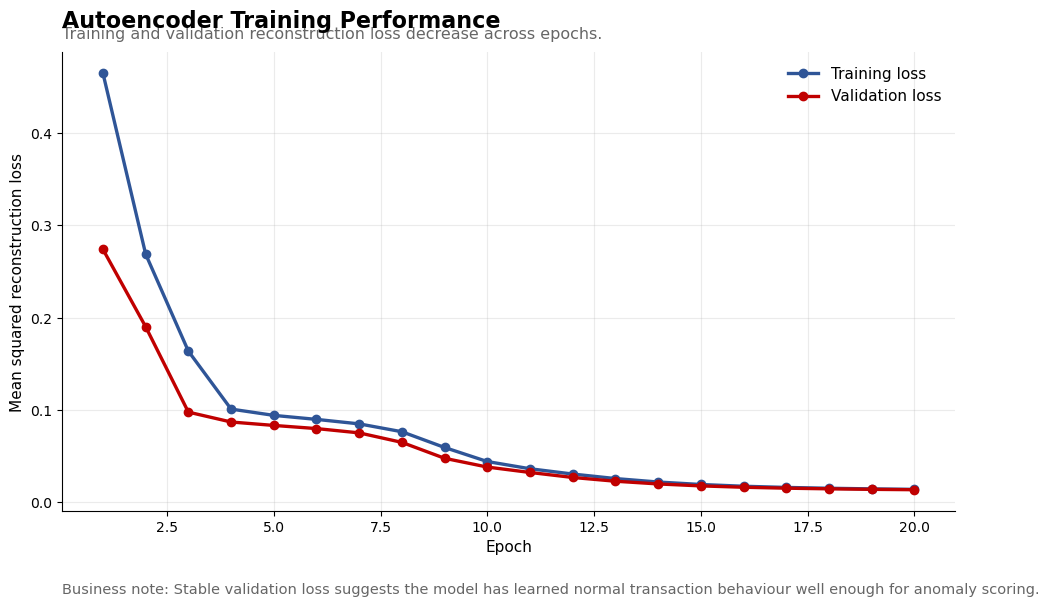

In [18]:
# ============================================================
# Step 16: BI-Ready Training Loss Chart
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6.2))

ax.plot(
    training_history_table["Epoch"],
    training_history_table["loss"],
    marker="o",
    linewidth=2.4,
    label="Training loss",
    color="#2F5597"
)

ax.plot(
    training_history_table["Epoch"],
    training_history_table["val_loss"],
    marker="o",
    linewidth=2.4,
    label="Validation loss",
    color="#C00000"
)

ax.set_title(
    "Autoencoder Training Performance",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.03,
    "Training and validation reconstruction loss decrease across epochs.",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#666666"
)

ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Mean squared reconstruction loss", fontsize=11)

ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0,
    -0.18,
    "Business note: Stable validation loss suggests the model has learned normal transaction behaviour well enough for anomaly scoring.",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#666666"
)

plt.tight_layout()
plt.show()

### Training Loss Chart — Conclusion

The training performance chart shows that the autoencoder learned steadily across 20 epochs.

Both training loss and validation loss decreased strongly.

By the final epoch:

| Metric | Final Value |
|---|---:|
| Training loss | 0.013953 |
| Validation loss | 0.013549 |

The validation loss stayed close to the training loss.

This suggests that the model learned normal transaction behaviour without obvious overfitting.

The trained autoencoder is now ready to calculate reconstruction error on the test set.

The next step is to compare reconstruction error for normal and fraud transactions.

## 17. Calculate Reconstruction Error on Test Data

Now we use the trained autoencoder to reconstruct the test transactions.

The test set contains both:

| Transaction Type | Purpose |
|---|---|
| Normal transactions | Check normal reconstruction error |
| Fraud transactions | Check whether suspicious records have higher error |

For each test transaction, we calculate reconstruction error.

Simple meaning:

`reconstruction error = difference between original transaction and reconstructed transaction`

If fraud transactions have higher reconstruction error, the autoencoder can support anomaly detection.

In [19]:
# ============================================================
# Step 17: Calculate Reconstruction Error on Test Data
# ============================================================

# Reconstruct test transactions using the trained autoencoder
test_reconstructions = autoencoder.predict(
    test_processed,
    verbose=0
)

# Calculate mean squared reconstruction error for each transaction
test_reconstruction_error = np.mean(
    np.square(test_processed - test_reconstructions),
    axis=1
)

# Create results table for analysis
anomaly_results = pd.DataFrame({
    "reconstruction_error": test_reconstruction_error,
    "isFraud": test_labels.values
})

anomaly_results["transaction_label"] = anomaly_results["isFraud"].map({
    0: "Normal Transaction",
    1: "Fraud Transaction"
})

print("Reconstruction error calculated successfully.")
print("Results shape:", anomaly_results.shape)

print("\nReconstruction error summary by class:")
display(
    anomaly_results
    .groupby("transaction_label")["reconstruction_error"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
)

Reconstruction error calculated successfully.
Results shape: (23213, 3)

Reconstruction error summary by class:


,transaction_label,count,mean,median,min,max
0,Fraud Transaction,8213,0.550486,0.110238,0.000566,28.858944
1,Normal Transaction,15000,0.013375,0.002064,0.000094,3.364668


### Reconstruction Error — Conclusion

The autoencoder calculated reconstruction error for each transaction in the test set.

The reconstruction error is much higher for fraud transactions than for normal transactions.

| Transaction Type | Count | Mean Error | Median Error |
|---|---:|---:|---:|
| Normal Transaction | 15,000 | 0.013375 | 0.002064 |
| Fraud Transaction | 8,213 | 0.550486 | 0.110238 |

This is a strong early result.

It means fraud transactions are generally harder for the autoencoder to reconstruct.

This supports the main anomaly detection idea:

`normal transaction → low reconstruction error`

`fraud transaction → higher reconstruction error`

The next step is to visualise the reconstruction error difference between normal and fraud transactions.

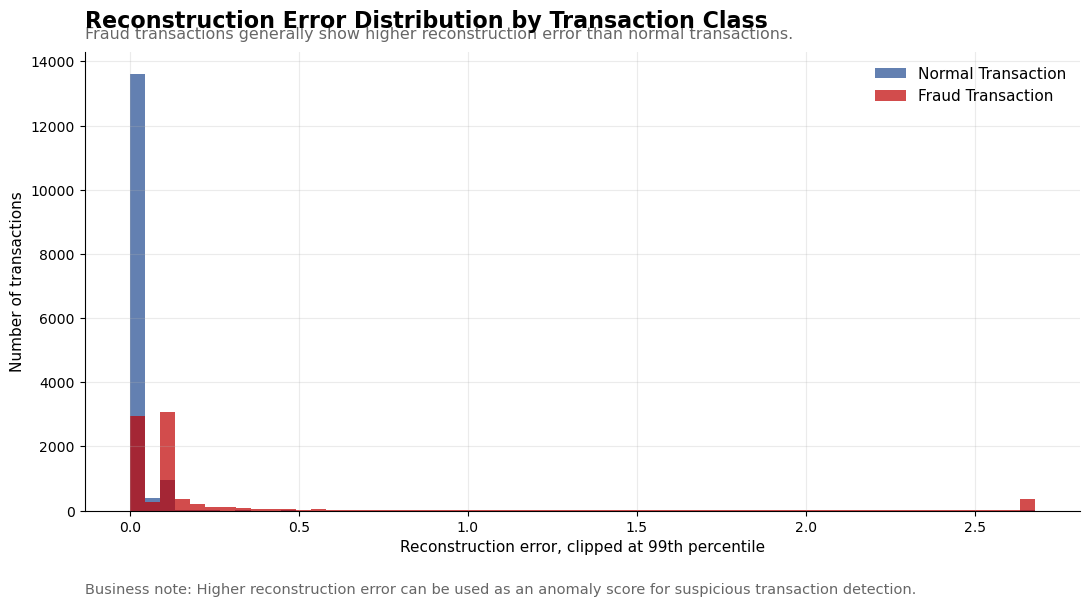

In [20]:
# ============================================================
# Step 18: Reconstruction Error Distribution by Class
# ============================================================

# Create chart data
error_chart_data = anomaly_results.copy()

# Clip extreme values only for better chart readability
# The original reconstruction_error values are not changed.
clip_limit = error_chart_data["reconstruction_error"].quantile(0.99)
error_chart_data["error_for_chart"] = error_chart_data["reconstruction_error"].clip(upper=clip_limit)

normal_errors = error_chart_data.loc[
    error_chart_data["transaction_label"] == "Normal Transaction",
    "error_for_chart"
]

fraud_errors = error_chart_data.loc[
    error_chart_data["transaction_label"] == "Fraud Transaction",
    "error_for_chart"
]

fig, ax = plt.subplots(figsize=(11, 6.2))

ax.hist(
    normal_errors,
    bins=60,
    alpha=0.75,
    label="Normal Transaction",
    color="#2F5597"
)

ax.hist(
    fraud_errors,
    bins=60,
    alpha=0.70,
    label="Fraud Transaction",
    color="#C00000"
)

ax.set_title(
    "Reconstruction Error Distribution by Transaction Class",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.03,
    "Fraud transactions generally show higher reconstruction error than normal transactions.",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#666666"
)

ax.set_xlabel("Reconstruction error, clipped at 99th percentile", fontsize=11)
ax.set_ylabel("Number of transactions", fontsize=11)

ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0,
    -0.18,
    "Business note: Higher reconstruction error can be used as an anomaly score for suspicious transaction detection.",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#666666"
)

plt.tight_layout()
plt.show()

### Reconstruction Error Distribution — Conclusion

The reconstruction error chart shows a clear difference between normal and fraud transactions.

Most normal transactions are concentrated near very low reconstruction error.

Fraud transactions are more spread out and have a much longer error range.

This supports the anomaly detection idea:

`normal transaction → easier to reconstruct → lower error`

`fraud transaction → harder to reconstruct → higher error`

There is still some overlap between normal and fraud transactions.

This means reconstruction error is useful, but not perfect.

The next step is to choose a threshold that converts reconstruction error into a suspicious transaction flag.

## 19. Set Anomaly Detection Threshold

Now we need to convert reconstruction error into a decision.

The model gives each transaction a reconstruction error.

To classify a transaction as suspicious, we need a threshold.

In this notebook, we use the **95th percentile of validation reconstruction error**.

The validation set contains only normal transactions.

So the threshold means:

> If a transaction has reconstruction error higher than 95% of normal validation transactions, flag it as suspicious.

This is a simple and explainable rule for anomaly detection.

In [21]:
# ============================================================
# Step 19: Set Anomaly Detection Threshold
# ============================================================

# Reconstruct validation transactions
val_reconstructions = autoencoder.predict(
    val_processed,
    verbose=0
)

# Calculate reconstruction error for validation transactions
val_reconstruction_error = np.mean(
    np.square(val_processed - val_reconstructions),
    axis=1
)

# Threshold based on normal validation reconstruction error
anomaly_threshold = np.percentile(val_reconstruction_error, 95)

print("Validation reconstruction error summary:")
print("Mean:", round(val_reconstruction_error.mean(), 6))
print("Median:", round(np.median(val_reconstruction_error), 6))
print("95th percentile threshold:", round(anomaly_threshold, 6))

print("\nAnomaly rule:")
print("If reconstruction error > threshold, flag transaction as suspicious.")

Validation reconstruction error summary:
Mean: 0.013549
Median: 0.002067
95th percentile threshold: 0.098729

Anomaly rule:
If reconstruction error > threshold, flag transaction as suspicious.


### Anomaly Threshold — Conclusion

The anomaly threshold was calculated using the validation reconstruction error.

The validation set contains only normal transactions.

| Metric | Value |
|---|---:|
| Mean validation error | 0.013549 |
| Median validation error | 0.002067 |
| 95th percentile threshold | 0.098729 |

The selected threshold is **0.098729**.

This means:

`reconstruction error <= 0.098729 → normal`

`reconstruction error > 0.098729 → suspicious`

This threshold flags transactions that reconstruct worse than most normal validation transactions.

It gives us a simple and explainable anomaly detection rule.

## 20. Flag Suspicious Transactions

Now we apply the anomaly threshold to the test set.

Each transaction receives a prediction:

| Condition | Prediction |
|---|---|
| Reconstruction error <= threshold | Normal |
| Reconstruction error > threshold | Suspicious |

Then we compare the predicted suspicious flag with the actual fraud label.

This helps evaluate how well reconstruction error works for fraud detection.

In [22]:
# ============================================================
# Step 20: Flag Suspicious Transactions
# ============================================================

# Apply threshold to test reconstruction error
anomaly_results["predicted_suspicious"] = (
    anomaly_results["reconstruction_error"] > anomaly_threshold
).astype(int)

# Add readable prediction label
anomaly_results["prediction_label"] = anomaly_results["predicted_suspicious"].map({
    0: "Predicted Normal",
    1: "Predicted Suspicious"
})

# Create prediction summary
prediction_summary = (
    anomaly_results["prediction_label"]
    .value_counts()
    .rename_axis("Prediction")
    .reset_index(name="Transactions")
)

prediction_summary["Share %"] = (
    prediction_summary["Transactions"] / len(anomaly_results) * 100
).round(3)

print("Suspicious transaction flagging completed.")
display(prediction_summary)

print("\nActual fraud distribution in test set:")
display(
    anomaly_results["transaction_label"]
    .value_counts()
    .rename_axis("Actual Class")
    .reset_index(name="Transactions")
)

Suspicious transaction flagging completed.


,Prediction,Transactions,Share %
0,Predicted Normal,17492,75.354
1,Predicted Suspicious,5721,24.646



Actual fraud distribution in test set:


,Actual Class,Transactions
0,Normal Transaction,15000
1,Fraud Transaction,8213


### Suspicious Transaction Flagging — Conclusion

The threshold was applied to the test set.

| Prediction | Transactions | Share |
|---|---:|---:|
| Predicted Normal | 17,492 | 75.354% |
| Predicted Suspicious | 5,721 | 24.646% |

The model flagged **5,721 transactions** as suspicious.

The actual test set contains:

| Actual Class | Transactions |
|---|---:|
| Normal Transaction | 15,000 |
| Fraud Transaction | 8,213 |

The test set contains a much higher fraud share than the original full dataset because all fraud records were kept for evaluation.

This means the suspicious share in the test set should not be interpreted as the real business fraud rate.

The next step is to compare predicted suspicious transactions with actual fraud labels using a confusion matrix and classification metrics.

## 21. Evaluate Anomaly Detection Performance

Now we compare the model prediction with the actual fraud label.

The model prediction is based on reconstruction error:

`high reconstruction error → predicted suspicious`

The actual label is:

`isFraud`

We evaluate using:

| Metric | Meaning |
|---|---|
| True Negative | Normal transaction correctly predicted normal |
| False Positive | Normal transaction wrongly flagged suspicious |
| False Negative | Fraud transaction missed by the model |
| True Positive | Fraud transaction correctly flagged suspicious |

This helps us understand whether reconstruction error is useful for detecting fraud.

In [23]:
# ============================================================
# Step 21: Evaluate Predictions with Confusion Matrix
# ============================================================

# Actual fraud labels
actual_fraud = anomaly_results["isFraud"]

# Predicted suspicious labels
predicted_suspicious = anomaly_results["predicted_suspicious"]

# Confusion matrix
confusion_values = confusion_matrix(actual_fraud, predicted_suspicious)

true_negative, false_positive, false_negative, true_positive = confusion_values.ravel()

confusion_summary = pd.DataFrame({
    "Metric": [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    "Meaning": [
        "Normal transaction correctly predicted normal",
        "Normal transaction wrongly flagged suspicious",
        "Fraud transaction missed by the model",
        "Fraud transaction correctly flagged suspicious"
    ],
    "Transactions": [
        true_negative,
        false_positive,
        false_negative,
        true_positive
    ]
})

display(confusion_summary)

print("Classification report:")
print(
    classification_report(
        actual_fraud,
        predicted_suspicious,
        target_names=["Normal Transaction", "Fraud Transaction"]
    )
)

,Metric,Meaning,Transactions
0,True Negative,Normal transaction correctly predicted normal,14247
1,False Positive,Normal transaction wrongly flagged suspicious,753
2,False Negative,Fraud transaction missed by the model,3245
3,True Positive,Fraud transaction correctly flagged suspicious,4968


Classification report:
                    precision    recall  f1-score   support

Normal Transaction       0.81      0.95      0.88     15000
 Fraud Transaction       0.87      0.60      0.71      8213

          accuracy                           0.83     23213
         macro avg       0.84      0.78      0.80     23213
      weighted avg       0.83      0.83      0.82     23213



### Anomaly Detection Evaluation — Conclusion

The anomaly detector was evaluated by comparing predicted suspicious transactions with the actual fraud labels.

The model used reconstruction error as the anomaly score.

| Class | Precision | Recall | F1-score |
|---|---:|---:|---:|
| Normal Transaction | 0.81 | 0.95 | 0.88 |
| Fraud Transaction | 0.87 | 0.60 | 0.71 |

---

#### Main Findings

The model achieved **87% precision** for fraud transactions.

This means that when the model flagged a transaction as suspicious, it was often correct.

However, fraud recall was **60%**.

This means the model detected 60% of actual fraud transactions and missed around 40%.

---

#### Business Meaning

The current threshold gives a conservative fraud detection model.

It produces relatively high-quality suspicious alerts, but it does not catch all fraud cases.

For fraud detection, recall is usually very important because missed fraud can create financial loss.

The next step is to test different thresholds and understand the trade-off between precision and recall.

## 22. Compare Different Anomaly Thresholds

The anomaly threshold controls how many transactions are flagged as suspicious.

A lower threshold flags more transactions.

A higher threshold flags fewer transactions.

| Threshold Choice | Expected Result |
|---|---|
| Lower threshold | Higher recall, more false positives |
| Higher threshold | Higher precision, more missed fraud |

In fraud detection, threshold choice is a business decision.

A bank may prefer higher recall if missing fraud is very costly.

A fraud investigation team may prefer higher precision if they have limited review capacity.

In [24]:
# ============================================================
# Step 22: Compare Different Anomaly Thresholds
# ============================================================

threshold_percentiles = [90, 92.5, 95, 97.5, 99]

threshold_results = []

actual_fraud = anomaly_results["isFraud"]

for percentile in threshold_percentiles:
    threshold_value = np.percentile(val_reconstruction_error, percentile)
    
    predicted_suspicious_at_threshold = (
        anomaly_results["reconstruction_error"] > threshold_value
    ).astype(int)
    
    precision = precision_score(actual_fraud, predicted_suspicious_at_threshold)
    recall = recall_score(actual_fraud, predicted_suspicious_at_threshold)
    f1 = f1_score(actual_fraud, predicted_suspicious_at_threshold)
    
    flagged_transactions = predicted_suspicious_at_threshold.sum()
    flagged_share = flagged_transactions / len(anomaly_results) * 100
    
    threshold_results.append({
        "Threshold Percentile": percentile,
        "Threshold Value": threshold_value,
        "Flagged Transactions": flagged_transactions,
        "Flagged Share %": flagged_share,
        "Fraud Precision": precision,
        "Fraud Recall": recall,
        "Fraud F1-score": f1
    })

threshold_comparison = pd.DataFrame(threshold_results)

display(
    threshold_comparison.round({
        "Threshold Value": 6,
        "Flagged Share %": 3,
        "Fraud Precision": 3,
        "Fraud Recall": 3,
        "Fraud F1-score": 3
    })
)

,Threshold Percentile,Threshold Value,Flagged Transactions,Flagged Share %,Fraud Precision,Fraud Recall,Fraud F1-score
0,90.0,0.031466,6935,29.876,0.781,0.660,0.715
1,92.5,0.084414,6106,26.304,0.823,0.612,0.702
2,95.0,0.098729,5721,24.646,0.868,0.605,0.713
3,97.5,0.107839,5116,22.039,0.925,0.576,0.710
4,99.0,0.118975,2336,10.063,0.933,0.265,0.413


| Threshold | Precision | Recall | Meaning                                   |
| --------- | --------: | -----: | ----------------------------------------- |
| 90%       |     0.781 |  0.660 | Catches more fraud, but more false alarms |
| 95%       |     0.868 |  0.605 | Balanced, fewer false alarms              |
| 97.5%     |     0.925 |  0.576 | Very precise, but misses more fraud       |
| 99%       |     0.933 |  0.265 | Too strict, misses too much fraud         |


### Threshold Comparison — Conclusion

Different anomaly thresholds create different business trade-offs.

| Threshold Percentile | Fraud Precision | Fraud Recall | Fraud F1-score | Business Meaning |
|---:|---:|---:|---:|---|
| 90.0 | 0.781 | 0.660 | 0.715 | Catches more fraud but creates more false alerts |
| 92.5 | 0.823 | 0.612 | 0.702 | Slightly fewer alerts with lower recall |
| 95.0 | 0.868 | 0.605 | 0.713 | Balanced threshold with strong precision |
| 97.5 | 0.925 | 0.576 | 0.710 | Very precise but misses more fraud |
| 99.0 | 0.933 | 0.265 | 0.413 | Too strict and misses too many fraud cases |

---

#### Main Finding

The **95th percentile threshold** gives a strong practical balance.

It achieves:

| Metric | Value |
|---|---:|
| Fraud precision | 0.868 |
| Fraud recall | 0.605 |
| Fraud F1-score | 0.713 |

The 90th percentile threshold catches slightly more fraud, but creates more false alerts.

The 99th percentile threshold has high precision, but recall drops sharply.

This means it misses too many fraud cases.

---

#### Business Takeaway

Threshold choice is a business decision.

If the fraud team wants to catch more fraud, a lower threshold may be better.

If the fraud team has limited review capacity and wants fewer false alerts, a higher threshold may be better.

For this notebook, the **95th percentile threshold** is a good balanced choice.

## 23. Visualise Threshold Trade-Off

Now we visualise how precision, recall, and F1-score change across thresholds.

This chart helps show the business trade-off clearly.

A lower threshold catches more fraud but flags more transactions.

A higher threshold gives cleaner alerts but misses more fraud.

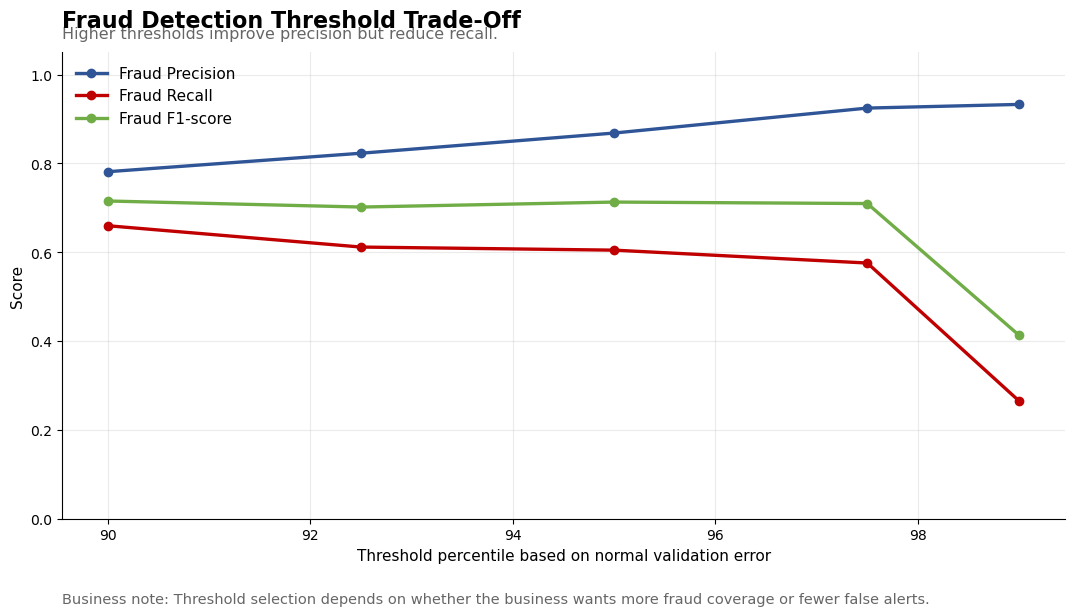

In [25]:
# ============================================================
# Step 23: BI Chart - Threshold Trade-Off
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6.3))

ax.plot(
    threshold_comparison["Threshold Percentile"],
    threshold_comparison["Fraud Precision"],
    marker="o",
    linewidth=2.4,
    label="Fraud Precision",
    color="#2F5597"
)

ax.plot(
    threshold_comparison["Threshold Percentile"],
    threshold_comparison["Fraud Recall"],
    marker="o",
    linewidth=2.4,
    label="Fraud Recall",
    color="#C00000"
)

ax.plot(
    threshold_comparison["Threshold Percentile"],
    threshold_comparison["Fraud F1-score"],
    marker="o",
    linewidth=2.4,
    label="Fraud F1-score",
    color="#70AD47"
)

ax.set_title(
    "Fraud Detection Threshold Trade-Off",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.03,
    "Higher thresholds improve precision but reduce recall.",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#666666"
)

ax.set_xlabel("Threshold percentile based on normal validation error", fontsize=11)
ax.set_ylabel("Score", fontsize=11)

ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0,
    -0.18,
    "Business note: Threshold selection depends on whether the business wants more fraud coverage or fewer false alerts.",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#666666"
)

plt.tight_layout()
plt.show()

### Threshold Trade-Off Chart — Conclusion

The threshold trade-off chart shows how model behaviour changes when the anomaly threshold changes.

As the threshold becomes higher:

- fraud precision increases,
- fraud recall decreases,
- fewer transactions are flagged as suspicious.

This means the model becomes stricter.

At the **99th percentile threshold**, precision is high, but recall drops sharply.

This means the model flags cleaner suspicious cases, but misses many fraud transactions.

The **95th percentile threshold** gives a more practical balance between precision and recall.

For this notebook, we continue with the **95th percentile threshold** because it provides strong precision while still detecting a meaningful share of fraud cases.

## 24. Confusion Matrix for Selected Threshold

Now we visualise the confusion matrix for the selected 95th percentile threshold.

The confusion matrix shows four outcomes:

| Outcome | Meaning |
|---|---|
| True Negative | Normal transaction correctly predicted normal |
| False Positive | Normal transaction wrongly flagged suspicious |
| False Negative | Fraud transaction missed |
| True Positive | Fraud transaction correctly flagged suspicious |

This chart helps us understand how useful the anomaly detector is for fraud investigation.

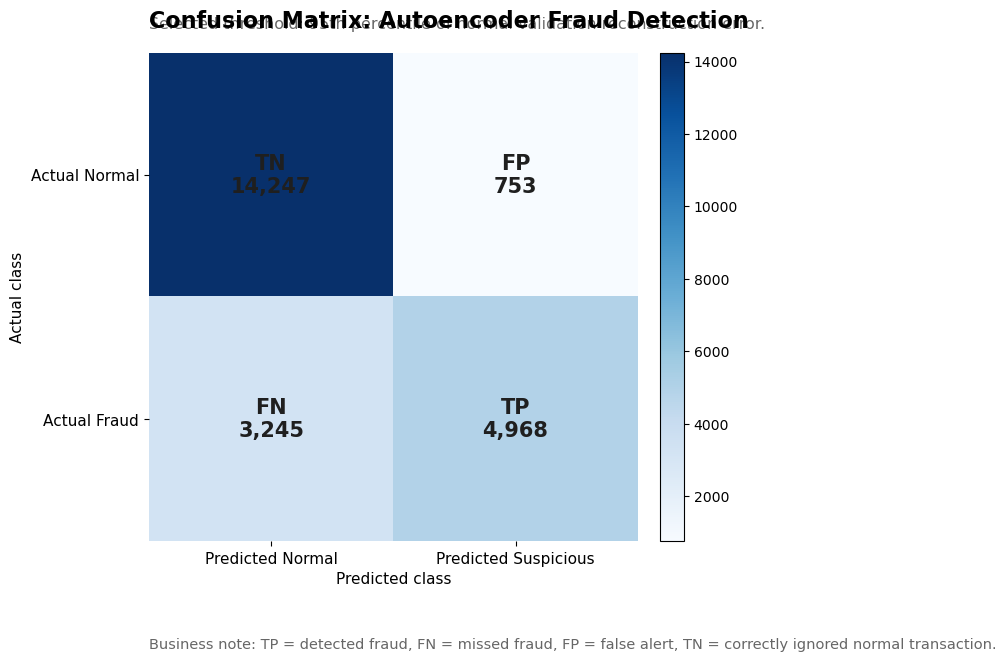

In [27]:
# ============================================================
# Step 24: BI Chart - Confusion Matrix with TN, FP, FN, TP
# ============================================================

# Create labelled confusion matrix values
confusion_matrix_labels = np.array([
    [f"TN\n{true_negative:,.0f}", f"FP\n{false_positive:,.0f}"],
    [f"FN\n{false_negative:,.0f}", f"TP\n{true_positive:,.0f}"]
])

confusion_matrix_values = np.array([
    [true_negative, false_positive],
    [false_negative, true_positive]
])

fig, ax = plt.subplots(figsize=(8.8, 6.8))

matrix_image = ax.imshow(confusion_matrix_values, cmap="Blues")

# Add TN, FP, FN, TP labels inside cells
for row_index in range(confusion_matrix_values.shape[0]):
    for col_index in range(confusion_matrix_values.shape[1]):
        ax.text(
            col_index,
            row_index,
            confusion_matrix_labels[row_index, col_index],
            ha="center",
            va="center",
            fontsize=15,
            fontweight="bold",
            color="#1F1F1F"
        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Predicted Normal", "Predicted Suspicious"], fontsize=11)
ax.set_yticklabels(["Actual Normal", "Actual Fraud"], fontsize=11)

ax.set_title(
    "Confusion Matrix: Autoencoder Fraud Detection",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=18
)

ax.text(
    0,
    1.05,
    "Selected threshold: 95th percentile of normal validation reconstruction error.",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#666666"
)

ax.set_xlabel("Predicted class", fontsize=11)
ax.set_ylabel("Actual class", fontsize=11)

for spine in ax.spines.values():
    spine.set_visible(False)

colorbar = plt.colorbar(matrix_image, ax=ax, fraction=0.046, pad=0.04)
colorbar.ax.tick_params(labelsize=10)

ax.text(
    0,
    -0.22,
    "Business note: TP = detected fraud, FN = missed fraud, FP = false alert, TN = correctly ignored normal transaction.",
    transform=ax.transAxes,
    fontsize=10.5,
    color="#666666"
)

plt.tight_layout()
plt.show()

### Confusion Matrix — Conclusion

The confusion matrix shows the fraud detection results at the selected 95th percentile threshold.

| Term | Count | Meaning |
|---|---:|---|
| **TN** | 14,247 | Normal transactions correctly predicted as normal |
| **FP** | 753 | Normal transactions wrongly flagged as suspicious |
| **FN** | 3,245 | Fraud transactions missed by the model |
| **TP** | 4,968 | Fraud transactions correctly flagged as suspicious |

---

#### Main Interpretation

The model correctly detected **4,968 fraud transactions**.

It also missed **3,245 fraud transactions**.

This means the model is useful for identifying suspicious transactions, but it does not catch all fraud cases.

The false positive count is **753**, meaning some normal transactions were wrongly flagged as suspicious.

---

#### Business Meaning

The model creates a useful fraud investigation signal.

However, the threshold still needs business tuning.

If the business wants to catch more fraud, the threshold can be lowered.

If the business wants fewer false alerts, the threshold can be raised.

## 25. Business KPI Summary

Now we convert the confusion matrix results into business KPIs.

These KPIs help explain the fraud detection performance in simple business language.

| KPI | Meaning |
|---|---|
| Fraud precision | How reliable suspicious alerts are |
| Fraud recall | How much fraud the model catches |
| False positive rate | How often normal transactions are wrongly flagged |
| Missed fraud count | Fraud transactions not detected |
| Detected fraud count | Fraud transactions correctly flagged |

This makes the model result easier to communicate to business stakeholders.

In [28]:
# ============================================================
# Step 25: Business KPI Summary
# ============================================================

# Calculate business KPIs from confusion matrix values
fraud_precision = true_positive / (true_positive + false_positive)
fraud_recall = true_positive / (true_positive + false_negative)
fraud_f1 = 2 * (fraud_precision * fraud_recall) / (fraud_precision + fraud_recall)

false_positive_rate = false_positive / (false_positive + true_negative)
missed_fraud_rate = false_negative / (false_negative + true_positive)

business_kpi_summary = pd.DataFrame({
    "KPI": [
        "Detected Fraud Transactions",
        "Missed Fraud Transactions",
        "False Alerts",
        "Correctly Ignored Normal Transactions",
        "Fraud Precision",
        "Fraud Recall",
        "Fraud F1-score",
        "False Positive Rate",
        "Missed Fraud Rate"
    ],
    "Value": [
        f"{true_positive:,.0f}",
        f"{false_negative:,.0f}",
        f"{false_positive:,.0f}",
        f"{true_negative:,.0f}",
        f"{fraud_precision:.3f}",
        f"{fraud_recall:.3f}",
        f"{fraud_f1:.3f}",
        f"{false_positive_rate:.3f}",
        f"{missed_fraud_rate:.3f}"
    ],
    "Business Meaning": [
        "Fraud cases correctly flagged as suspicious",
        "Fraud cases not detected by the current threshold",
        "Normal transactions wrongly sent for investigation",
        "Normal transactions correctly left alone",
        "How many suspicious alerts are actually fraud",
        "How many actual fraud cases are detected",
        "Balance between fraud precision and recall",
        "Share of normal transactions wrongly flagged",
        "Share of fraud transactions missed"
    ]
})

display(business_kpi_summary)

,KPI,Value,Business Meaning
0,Detected Fraud Transactions,"4,968",Fraud cases correctly flagged as suspicious
1,Missed Fraud Transactions,"3,245",Fraud cases not detected by the current threshold
2,False Alerts,753,Normal transactions wrongly sent for investiga...
3,Correctly Ignored Normal Transactions,"14,247",Normal transactions correctly left alone
4,Fraud Precision,0.868,How many suspicious alerts are actually fraud
5,Fraud Recall,0.605,How many actual fraud cases are detected
6,Fraud F1-score,0.713,Balance between fraud precision and recall
7,False Positive Rate,0.050,Share of normal transactions wrongly flagged
8,Missed Fraud Rate,0.395,Share of fraud transactions missed


## Temporary Stopping Point

This notebook has completed the core autoencoder-based anomaly detection workflow.

Completed work:

- Loaded and prepared the PaySim financial transaction dataset
- Created a practical working sample
- Trained an autoencoder on normal transactions
- Calculated reconstruction error on test transactions
- Set an anomaly threshold using validation reconstruction error
- Flagged suspicious transactions
- Evaluated results using fraud labels
- Compared threshold trade-offs
- Created key BI-style charts

The remaining optional work is:

- final business interpretation,
- limitations and next steps,
- final notebook conclusion,
- and interview-style explanation.

These sections can be added later during final documentation.